In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()
df = pd.read_csv(output_dir / "cneuromod_citations.csv")
print(df)

      year          type  count
0   2020.0        Thesis      1
1   2022.0    Conference      1
2   2022.0       Journal      2
3   2023.0       Journal      3
4   2023.0      Preprint      2
5   2023.0        Thesis      1
6   2024.0       Journal      1
7   2024.0      Preprint      2
8   2024.0        Thesis      1
9   2025.0    Conference      1
10  2025.0       Journal      4
11  2025.0      Preprint     18
12  2025.0        Thesis      2
13  2026.0  Book Chapter      1
14  2026.0       Journal      1
15  2026.0      Preprint      4
16  2026.0        Thesis      1
17     NaN       Journal      1
18     NaN         Other      2


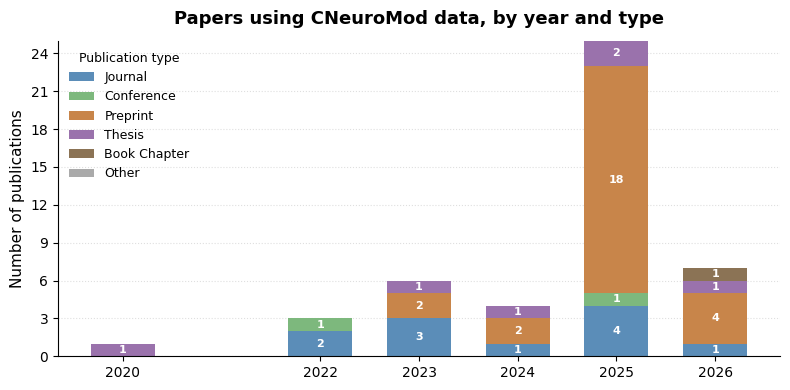

Saved cneuromod_citations.png


In [2]:
TYPE_ORDER = ["Journal", "Conference", "Preprint", "Thesis", "Book Chapter", "Other"]
TYPE_COLORS = {
    "Journal":     "#5B8DB8",
    "Conference":  "#7DB87D",
    "Preprint":    "#C8854A",
    "Thesis":      "#9A72AC",
    "Book Chapter":"#8B7355",
    "Other":       "#AAAAAA",
}

# Pivot: rows = year, columns = type
pivot = (
    df.pivot_table(index="year", columns="type", values="count", aggfunc="sum", fill_value=0)
    .reindex(columns=[t for t in TYPE_ORDER if t in df["type"].unique()], fill_value=0)
)

# Drop rows where year is NaN, sort chronologically
pivot = pivot[pivot.index.notna()].sort_index()
years = pivot.index.astype(int).tolist()

fig, ax = plt.subplots(figsize=(8, 4))

bottom = np.zeros(len(years))
for ptype in pivot.columns:
    counts = pivot[ptype].values
    bars = ax.bar(
        years, counts, bottom=bottom,
        color=TYPE_COLORS.get(ptype, "#888"),
        label=ptype, width=0.65, zorder=2,
    )
    # Label bars with count > 0
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            cy = bar.get_y() + bar.get_height() / 2
            ax.text(
                bar.get_x() + bar.get_width() / 2, cy,
                str(int(cnt)),
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="white", zorder=3,
            )
    bottom += counts

ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years], fontsize=10)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylabel("Number of publications", fontsize=11)
ax.set_title("Papers using CNeuroMod data, by year and type", fontsize=13, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left", frameon=False,
    fontsize=9, title="Publication type", title_fontsize=9,
)

plt.tight_layout()
out_path = output_dir / "cneuromod_citations.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out_path.name}")